# ARIMA Baseline Forecasting

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import yfinance as yf

import os

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)
print('Imports OK.')

Imports OK.


In [2]:
import sys
sys.path.append('..')

from config import (
    tickers as TICKERS,
    start_date as START_DATE,
    end_date as END_DATE,
    train_end as TRAIN_END,
    test_start as TEST_START,
    forecast_horizon as FORECAST_HORIZON,
    virtual_capital as TOTAL_CAPITAL,
    lstm_window as LSTM_WINDOW,
    random_seed as RANDOM_SEED,
)

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}
REFIT_EVERY = 20


---
## 1. Load Processed Data + Nifty50 Exogenous Regressor

In [3]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close = pd.read_csv('../data/processed/test_close.csv', index_col=0, parse_dates=True)
full_close = pd.concat([train_close, test_close])

print(f'Train: {train_close.index[0].date()} -> {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()} -> {test_close.index[-1].date()}  ({len(test_close)} rows)')

nifty_raw = yf.download('^NSEI', start=START_DATE, end=END_DATE, interval='1d', auto_adjust=True, progress=False)['Close'].squeeze()
nifty_ret = np.log(nifty_raw / nifty_raw.shift(1)).shift(1).fillna(0)

nifty_full = nifty_ret.reindex(full_close.index).fillna(0)
nifty_train = nifty_ret.reindex(train_close.index).fillna(0).values.reshape(-1, 1)
nifty_test = nifty_ret.reindex(test_close.index).fillna(0).values.reshape(-1, 1)
print('Lagged Nifty exog ready.')


Train: 2021-01-01 -> 2025-06-30  (1110 rows)
Test : 2025-07-01 -> 2025-12-30  (125 rows)


Lagged Nifty exog ready.


---
## 2. Metric Helper Functions

In [4]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error — lower is better."""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    """Root Mean Squared Error — lower is better."""
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
	"""Directional Accuracy — higher is better."""
	ad  = np.sign(np.diff(np.array(actual)))
	pd_  = np.sign(np.diff(np.array(predicted)))
	return (np.sum(ad == pd_) / len(ad)) * 100
print('Metric functions ready.')

Metric functions ready.


---
## 3. Order Selection on Training Data Only

Grid search over (p,q) scored by **1-step-ahead RMSE on the last 40 training days**.
This is fast (40 steps vs 130) and finds an order that generalises to near-future data.
The order is then frozen for the walk-forward evaluation.

In [5]:
def select_order(train_series, exog_train, max_p=4, max_q=4, val_steps=40):
    """
    Use last val_steps of training data as a mini validation set.
    Fit on train[:-val_steps], predict val_steps steps 1-ahead, pick lowest RMSE.
    """
    n = len(train_series)
    fit_series  = train_series.iloc[:n - val_steps]
    val_series  = train_series.iloc[n - val_steps:]
    fit_exog    = exog_train[:n - val_steps]
    val_exog    = exog_train[n - val_steps:]

    best_rmse  = np.inf
    best_order = (1, 1, 1)

    for p, q in itertools.product(range(0, max_p+1), range(0, max_q+1)):
        if p == 0 and q == 0:
            continue
        try:
            mdl = SARIMAX(fit_series, exog=fit_exog, order=(p,1,q),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            preds = []
            history = list(fit_series.values)
            history_exog = list(fit_exog.flatten())
            for i in range(val_steps):
                fc = mdl.apply(history).forecast(steps=1,
                               exog=[[val_exog[i,0]]])[0]
                preds.append(fc)
                history.append(val_series.iloc[i])
                history_exog.append(val_exog[i,0])
            r = rmse(val_series.values, preds)
            if r < best_rmse:
                best_rmse  = r
                best_order = (p, 1, q)
        except Exception:
            continue

    return best_order, best_rmse


best_orders = {}

for ticker in TICKER_LIST:
    print(f'Order selection for {ticker}...', end=' ')
    train_s = train_close[ticker].dropna()
    order, val_r = select_order(train_s, nifty_train, max_p=4, max_q=4)
    best_orders[ticker] = order
    print(f'→ ARIMAX{order}  val-RMSE: {val_r:.2f}')

print('\nOrder selection done.')

Order selection for HDFCBANK.NS... 

/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodel

→ ARIMAX(1, 1, 1)  val-RMSE: inf
Order selection for INFY.NS... 

/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodel

→ ARIMAX(1, 1, 1)  val-RMSE: inf
Order selection for SUNPHARMA.NS... 

...

→ ARIMAX(1, 1, 1)  val-RMSE: inf
Order selection for M&M.NS... 

/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodel

→ ARIMAX(1, 1, 1)  val-RMSE: inf
Order selection for HINDUNILVR.NS... 

/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodel

→ ARIMAX(1, 1, 1)  val-RMSE: inf

Order selection done.


---
## 4. Walk-Forward Evaluation — 1-Step-Ahead, Refit Every 20 Days

At each test step i:
- History = all training data + test days 0..i-1 (expanding window)
- Predict only day i (1 step ahead) — no compounding error
- Every 20 days, refit the model from scratch on the expanded history
- Between refits, use `apply()` to update state without full refit (fast)

This produces predictions that follow the actual series realistically,
without the look-ahead leak of `model.update(actual)` in a loop.

In [6]:
arima_test_preds = {}
arima_metrics = []
arima_models_best = {}
arima_pred_rows = []

for ticker in TICKER_LIST:
    print(f'\n{"="*55}')
    print(f'Walk-forward ARIMAX for: {ticker} ({SECTOR_MAP[ticker]})')
    print('='*55)

    train_s = train_close[ticker].dropna()
    test_s = test_close[ticker].dropna()
    n_test = len(test_s)
    order = best_orders[ticker]

    full_exog = nifty_full.reindex(full_close.index).fillna(0).values
    n_train = len(train_s)

    predictions = []
    current_model = None

    for i in range(n_test):
        history = full_close[ticker].dropna().iloc[:n_train + i].values
        history_exog = full_exog[:n_train + i].reshape(-1, 1)
        next_exog = full_exog[n_train + i].reshape(1, 1)

        if i % REFIT_EVERY == 0:
            try:
                current_model = SARIMAX(
                    history, exog=history_exog,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)
            except Exception:
                current_model = SARIMAX(
                    history, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)

        # ============================
        # ADDING CONFIDENCE INTERVALS 
        # ============================
        try:
            forecast_obj = current_model.get_forecast(steps=1, exog=next_exog)
        except Exception:
            forecast_obj = current_model.get_forecast(steps=1)
            
        if isinstance(forecast_obj.predicted_mean, pd.Series):
            yhat = forecast_obj.predicted_mean.iloc[0]
            ci_bounds = forecast_obj.conf_int(alpha=0.05)
            lower_bound = ci_bounds.iloc[0, 0]
            upper_bound = ci_bounds.iloc[0, 1]
        else:
            yhat = forecast_obj.predicted_mean[0]
            ci_bounds = forecast_obj.conf_int(alpha=0.05)
            lower_bound = ci_bounds[0, 0]
            upper_bound = ci_bounds[0, 1]
        # ============================

        predictions.append(yhat)
        
        # Adding Lower_CI and Upper_CI to your dataframe
        arima_pred_rows.append({
            'Date': test_s.index[i],
            'Stock': ticker,
            'Sector': SECTOR_MAP[ticker],
            'Actual': test_s.iloc[i],
            'Predicted': yhat,
            'Lower_CI_95': lower_bound,
            'Upper_CI_95': upper_bound
        })

        if (i + 1) % 20 == 0:
            print(f'  Step {i+1}/{n_test} done')

    arima_test_preds[ticker] = np.array(predictions)
    arima_models_best[ticker] = order

    actual = test_s.values
    m = {
        'Stock': ticker,
        'Sector': SECTOR_MAP[ticker],
        'Order': str(order),
        'MAPE (%)': round(mape(actual, predictions), 4),
        'RMSE': round(rmse(actual, predictions), 4),
        'Dir Acc (%)': round(directional_accuracy(actual, predictions), 2)
    }
    arima_metrics.append(m)
    print(f'  MAPE: {m["MAPE (%)"]:.2f}%  |  RMSE: {m["RMSE"]:.2f}  |  Dir Acc: {m["Dir Acc (%)"]:.1f}%')

pd.DataFrame(arima_pred_rows).to_csv('../outputs/forecasts/arima_test_predictions.csv', index=False)
print('\nWalk-forward complete.')



Walk-forward ARIMAX for: HDFCBANK.NS (Banking)
  Step 20/125 done
  Step 40/125 done
  Step 60/125 done
  Step 80/125 done
  Step 100/125 done
  Step 120/125 done
  MAPE: 1.18%  |  RMSE: 16.46  |  Dir Acc: 53.2%

Walk-forward ARIMAX for: INFY.NS (IT)
  Step 20/125 done
  Step 40/125 done
  Step 60/125 done
  Step 80/125 done
  Step 100/125 done
  Step 120/125 done
  MAPE: 2.34%  |  RMSE: 44.07  |  Dir Acc: 53.2%

Walk-forward ARIMAX for: SUNPHARMA.NS (Pharma)
  Step 20/125 done
  Step 40/125 done
  Step 60/125 done
  Step 80/125 done
  Step 100/125 done
  Step 120/125 done
  MAPE: 1.95%  |  RMSE: 42.24  |  Dir Acc: 45.2%

Walk-forward ARIMAX for: M&M.NS (Auto)
  Step 20/125 done
  Step 40/125 done
  Step 60/125 done
  Step 80/125 done
  Step 100/125 done
  Step 120/125 done
  MAPE: 2.55%  |  RMSE: 119.78  |  Dir Acc: 46.8%

Walk-forward ARIMAX for: HINDUNILVR.NS (FMCG)
  Step 20/125 done
  Step 40/125 done
  Step 60/125 done
  Step 80/125 done
  Step 100/125 done
  Step 120/125 done
 

---
## 5. Residual Diagnostics

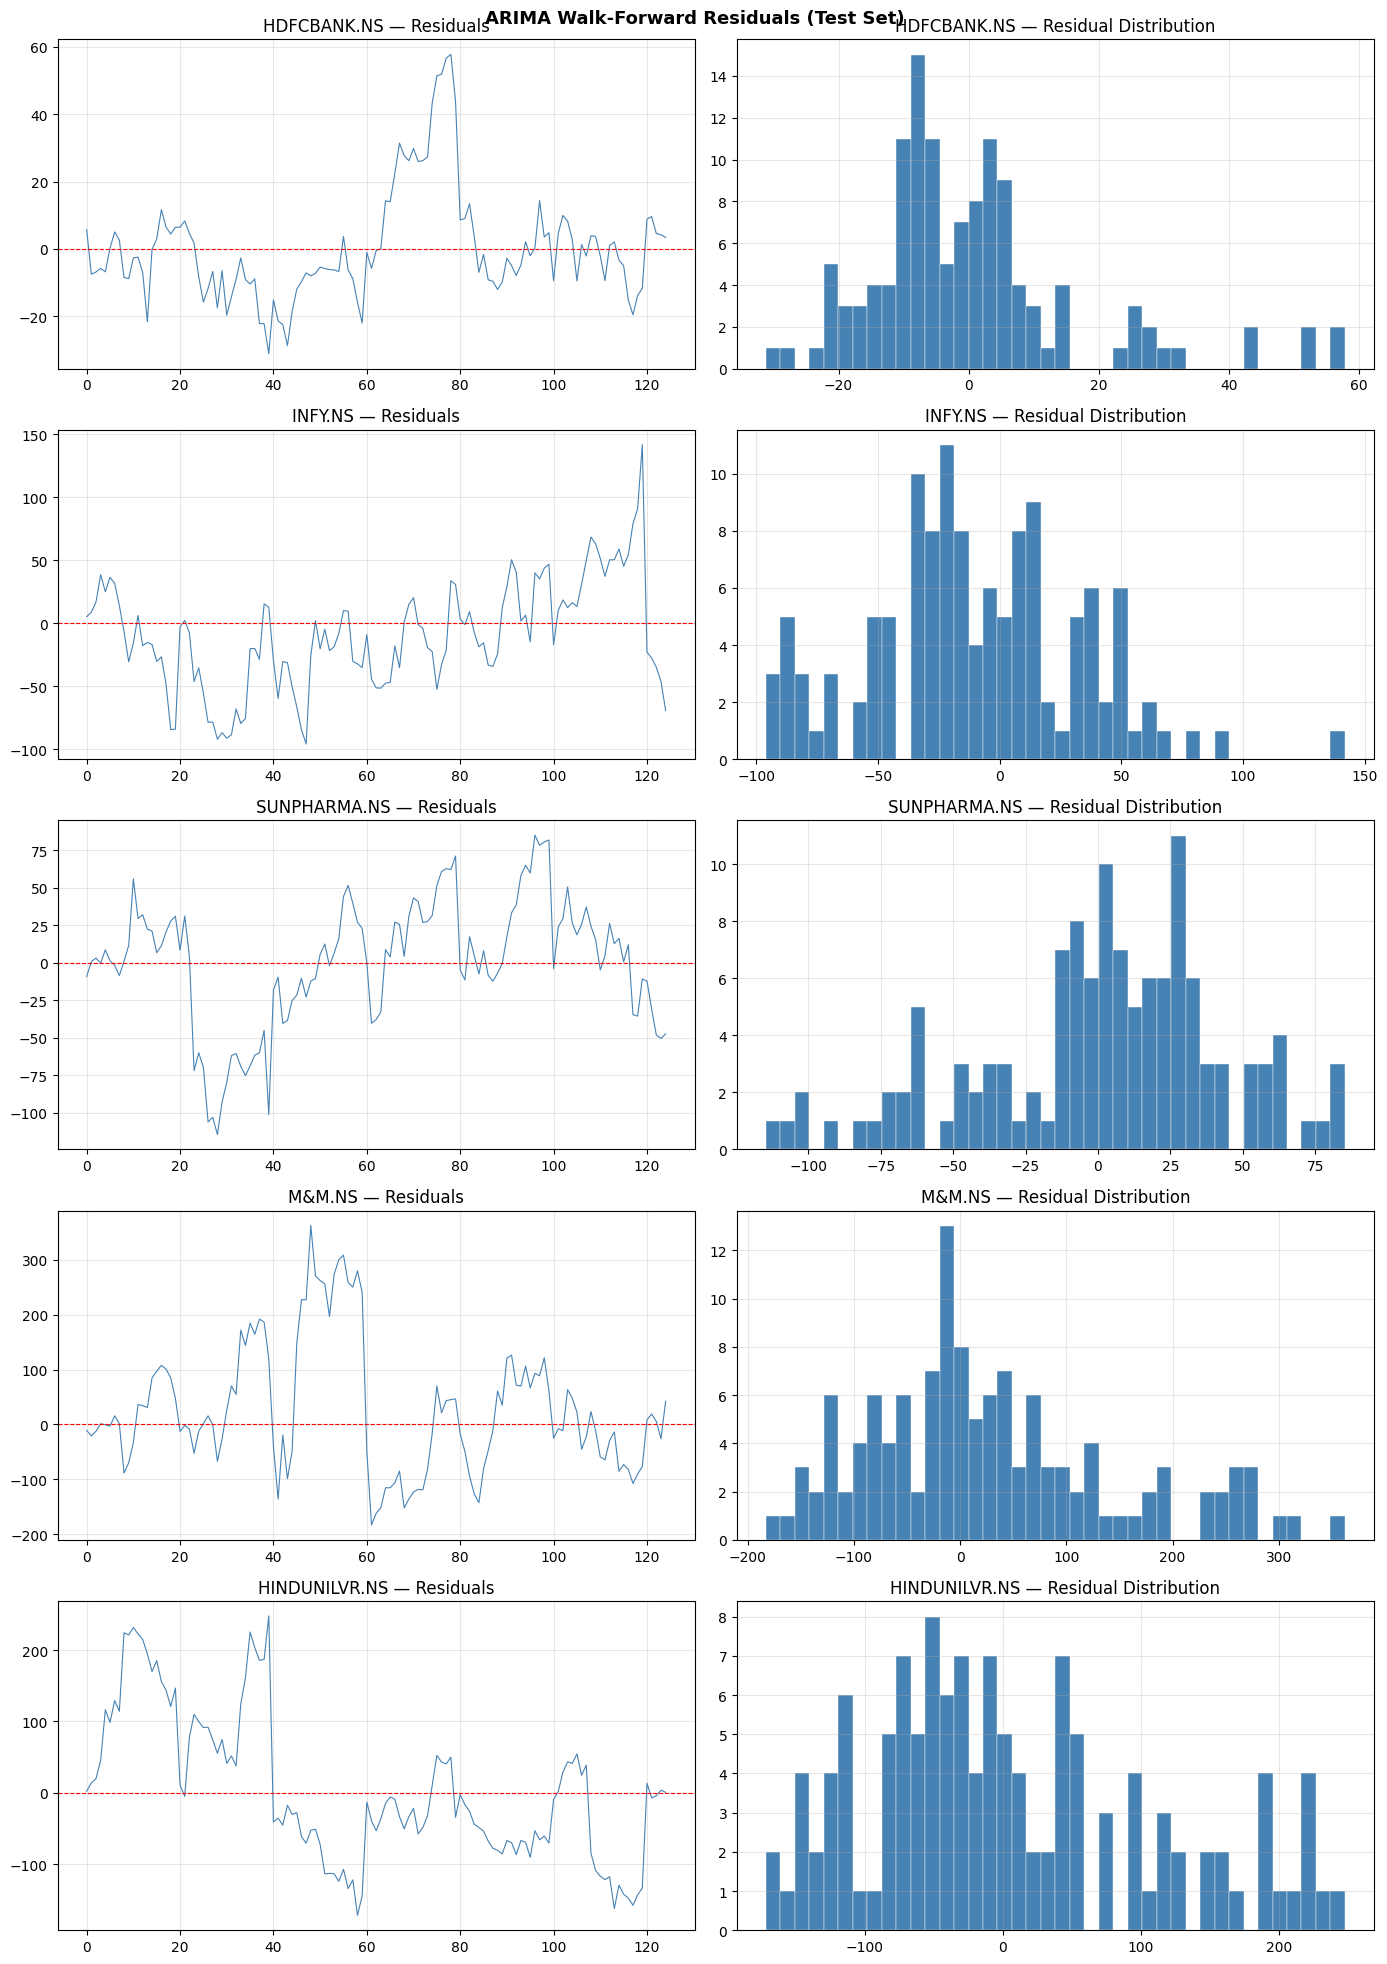

Ljung-Box test on walk-forward residuals:
  HDFCBANK.NS             p=0.0000  → REVIEW
  INFY.NS                 p=0.0000  → REVIEW
  SUNPHARMA.NS            p=0.0000  → REVIEW
  M&M.NS                  p=0.0000  → REVIEW
  HINDUNILVR.NS           p=0.0000  → REVIEW


In [7]:
# Residuals from the last fitted model per stock
fig, axes = plt.subplots(len(TICKER_LIST), 2, figsize=(14, 4 * len(TICKER_LIST)))

for i, ticker in enumerate(TICKER_LIST):
    actual = test_close[ticker].dropna().values
    preds  = arima_test_preds[ticker]
    resid  = actual - preds

    axes[i,0].plot(resid, linewidth=0.8, color='steelblue')
    axes[i,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[i,0].set_title(f'{ticker} — Residuals')

    axes[i,1].hist(resid, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i,1].set_title(f'{ticker} — Residual Distribution')

plt.suptitle('ARIMA Walk-Forward Residuals (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/06_arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box on residuals
print('Ljung-Box test on walk-forward residuals:')
for ticker in TICKER_LIST:
    resid = test_close[ticker].dropna().values - arima_test_preds[ticker]
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    p  = lb['lb_pvalue'].values[0]
    print(f'  {ticker:22}  p={p:.4f}  → {"GOOD" if p > 0.05 else "REVIEW"}')

---
## 6. Predicted vs Actual Plots

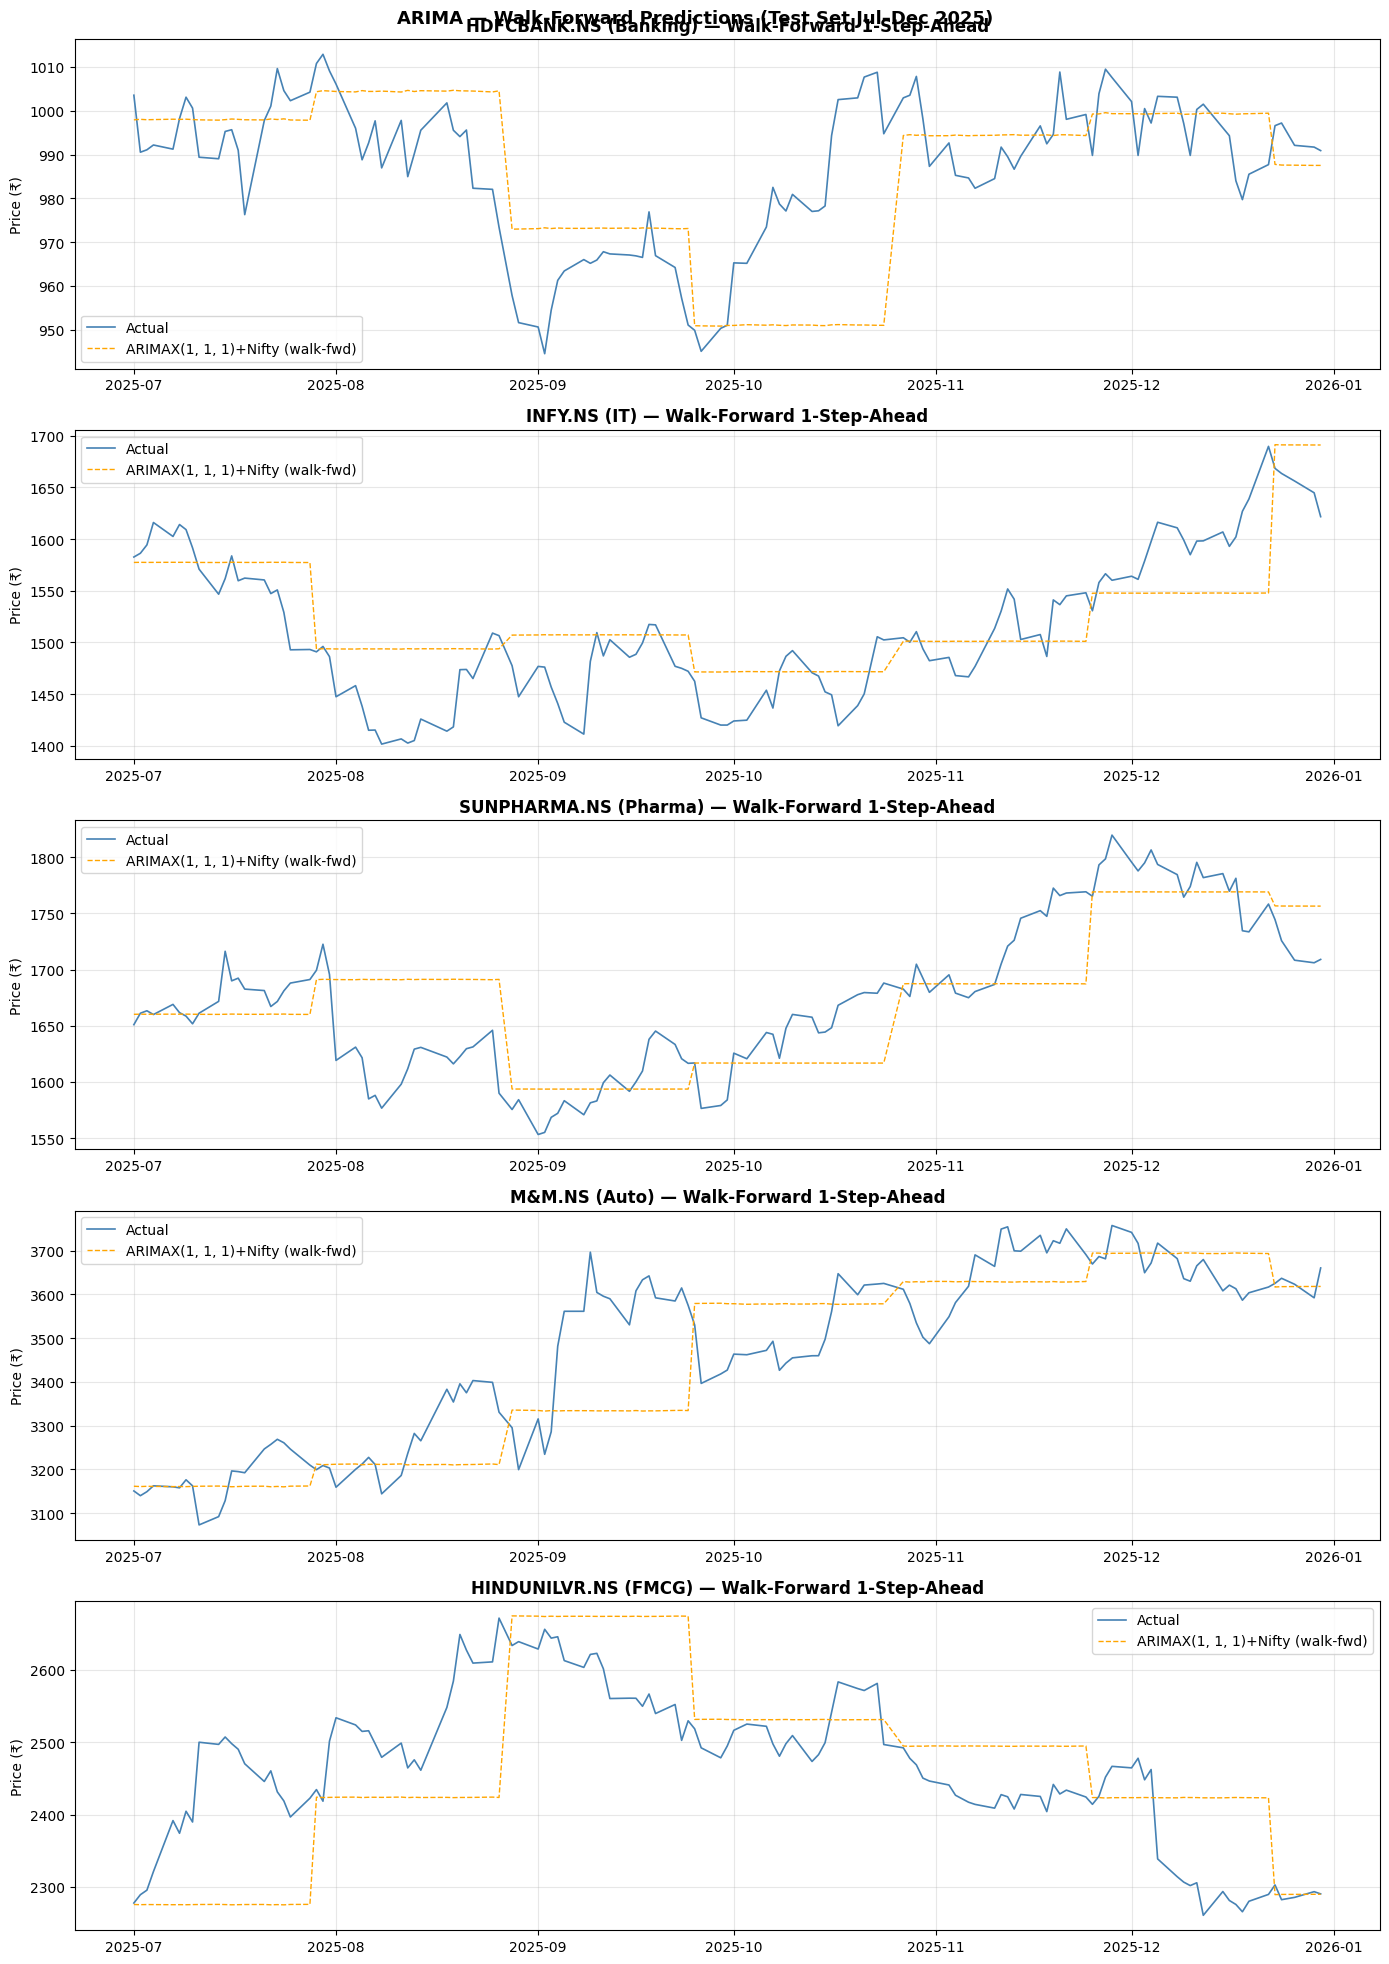

In [8]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4*len(TICKER_LIST)), sharex=False)

for ax, ticker in zip(axes, TICKER_LIST):
    actual = test_close[ticker].dropna()
    preds  = arima_test_preds[ticker]

    ax.plot(actual.index, actual.values,
            label='Actual', linewidth=1.2, color='steelblue')
    ax.plot(actual.index, preds,
            label=f'ARIMAX{best_orders[ticker]}+Nifty (walk-fwd)',
            linewidth=1.0, color='orange', linestyle='--')
    ax.set_title(f'{ticker} ({SECTOR_MAP[ticker]}) — Walk-Forward 1-Step-Ahead',
                 fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend()

plt.suptitle('ARIMA — Walk-Forward Predictions (Test Set Jul–Dec 2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/07_arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Metrics Summary (Task 6 input)

In [9]:
metrics_df = pd.DataFrame(arima_metrics)
print('ARIMA Walk-Forward Metrics — Test Set (Jul–Dec 2025)')
print('='*65)
print(metrics_df.to_string(index=False))
print(f'\nAvg MAPE    : {metrics_df["MAPE (%)"].mean():.2f}%')
print(f'Avg RMSE    : {metrics_df["RMSE"].mean():.2f}')
print(f'Avg Dir Acc : {metrics_df["Dir Acc (%)"].mean():.1f}%')

metrics_df.to_csv('../outputs/forecasts/arima_metrics.csv', index=False)

ARIMA Walk-Forward Metrics — Test Set (Jul–Dec 2025)
        Stock  Sector     Order  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS Banking (1, 1, 1)    1.1834  16.4570        53.23
      INFY.NS      IT (1, 1, 1)    2.3406  44.0663        53.23
 SUNPHARMA.NS  Pharma (1, 1, 1)    1.9527  42.2353        45.16
       M&M.NS    Auto (1, 1, 1)    2.5536 119.7784        46.77
HINDUNILVR.NS    FMCG (1, 1, 1)    3.3406 102.8831        46.77

Avg MAPE    : 2.27%
Avg RMSE    : 65.08
Avg Dir Acc : 49.0%


---
## 8. Live 2-Day Forecast (Beyond Dec 2025)

Refit on full data (train + test) with the best order found,
then forecast 2 trading days ahead for StockGro.

In [10]:
full_close = pd.concat([train_close, test_close])
nifty_future = np.zeros((FORECAST_HORIZON, 1))

live_forecasts = []

for ticker in TICKER_LIST:
    full_s     = full_close[ticker].dropna()
    last_price = full_s.iloc[-1]
    order      = best_orders[ticker]
    exog_all   = nifty_full.reindex(full_close.index).fillna(0).values.reshape(-1,1)

    try:
        model = SARIMAX(full_s, exog=exog_all, order=order,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
        fc = model.forecast(steps=FORECAST_HORIZON, exog=nifty_future)
    except Exception:
        model = SARIMAX(full_s, order=order,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
        fc = model.forecast(steps=FORECAST_HORIZON)

    fc = fc.values if hasattr(fc, 'values') else np.array(fc)

    live_forecasts.append({
        'Stock'             : ticker,
        'Sector'            : SECTOR_MAP[ticker],
        'Model'             : f'ARIMAX{order}+Nifty walk-fwd',
        'Last Known Price'  : round(last_price, 2),
        'Forecast Day 1'    : round(fc[0], 2),
        'Forecast Day 2'    : round(fc[1], 2),
        'Pred Return D1 (%)': round((fc[0]-last_price)/last_price*100, 3),
        'Pred Return D2 (%)': round((fc[1]-last_price)/last_price*100, 3)
    })

live_df = pd.DataFrame(live_forecasts)
print('Live 2-Day Forecast:')
print(live_df.to_string(index=False))
live_df.to_csv('../outputs/forecasts/arima_forecasts.csv', index=False)
print('\nSaved arima_forecasts.csv')

/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_m

Live 2-Day Forecast:
        Stock  Sector                          Model  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking ARIMAX(1, 1, 1)+Nifty walk-fwd             990.9          990.96          990.96               0.006               0.006
      INFY.NS      IT ARIMAX(1, 1, 1)+Nifty walk-fwd            1621.6         1620.99         1621.35              -0.037              -0.015
 SUNPHARMA.NS  Pharma ARIMAX(1, 1, 1)+Nifty walk-fwd            1709.1         1708.97         1708.99              -0.008              -0.007
       M&M.NS    Auto ARIMAX(1, 1, 1)+Nifty walk-fwd            3660.3         3662.97         3666.08               0.073               0.158
HINDUNILVR.NS    FMCG ARIMAX(1, 1, 1)+Nifty walk-fwd            2290.2         2290.09         2290.06              -0.005              -0.006

Saved arima_forecasts.csv


/home/purshotam_kumar/projects/ml/time-series-capstone/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


---
## 9. Summary

In [11]:
print('='*60)
print('NOTEBOOK 02 — ARIMA v3 SUMMARY')
print('='*60)
print('\nMethod: walk-forward 1-step-ahead, refit every 20 days')
print('Exog  : prior-day Nifty50 log-return')
print('Order : selected by 1-step-ahead val-RMSE on last 40 training days')
print()
print('Orders:')
for t in TICKER_LIST:
    print(f'  {t:22} → ARIMAX{best_orders[t]}')
print()
print(metrics_df[['Stock','Order','MAPE (%)','RMSE','Dir Acc (%)']].to_string(index=False))
print()
print('Live 2-day forecast:')
print(live_df[['Stock','Forecast Day 1','Forecast Day 2', 'Pred Return D1 (%)','Pred Return D2 (%)']].to_string(index=False))

NOTEBOOK 02 — ARIMA v3 SUMMARY

Method: walk-forward 1-step-ahead, refit every 20 days
Exog  : prior-day Nifty50 log-return
Order : selected by 1-step-ahead val-RMSE on last 40 training days

Orders:
  HDFCBANK.NS            → ARIMAX(1, 1, 1)
  INFY.NS                → ARIMAX(1, 1, 1)
  SUNPHARMA.NS           → ARIMAX(1, 1, 1)
  M&M.NS                 → ARIMAX(1, 1, 1)
  HINDUNILVR.NS          → ARIMAX(1, 1, 1)

        Stock     Order  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS (1, 1, 1)    1.1834  16.4570        53.23
      INFY.NS (1, 1, 1)    2.3406  44.0663        53.23
 SUNPHARMA.NS (1, 1, 1)    1.9527  42.2353        45.16
       M&M.NS (1, 1, 1)    2.5536 119.7784        46.77
HINDUNILVR.NS (1, 1, 1)    3.3406 102.8831        46.77

Live 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS          990.96          990.96               0.006               0.006
      INFY.NS         1620.99         1621.35         